In [1]:
import numpy as np
import xgi
from xgi.dynamics.synchronization import simulate_kuramoto,simulate_simplicial_kuramoto
n = 120
H = xgi.random_hypergraph(n, [0.05, 0.001], seed=42)
omega = 2*np.ones(n)
theta = np.linspace(0, 2*np.pi, n)
theta_time, times = simulate_kuramoto(H, k2=1, k3=3, omega=omega, theta=theta)

/home/kslote/anaconda3/envs/epilepsy_mds/lib/python3.9/site-packages/xgi/generators/random.py:154: UserWarning: This method is much slower than fast_random_hypergraph
  warn("This method is much slower than fast_random_hypergraph")


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot phase evolution over time
plt.figure(figsize=(10, 4))
plt.imshow(theta_time.T, aspect='auto', cmap='twilight')
plt.colorbar(label='Phase')
plt.xlabel('Time step')
plt.ylabel('Oscillator index')
plt.title('Phase evolution of Kuramoto oscillators')

# Plot order parameter
r = np.abs(np.mean(np.exp(1j * theta_time), axis=1))
plt.figure(figsize=(10, 3))
plt.plot(times, r)
plt.xlabel('Time')
plt.ylabel('Order parameter')
plt.title('Synchronization order parameter')
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(times, theta_time)  # times on x-axis, phase values on y-axis
plt.xlabel('Time')
plt.ylabel('Phase θ')
plt.title('Kuramoto Oscillator Phases')
plt.show()

In [ ]:
n_oscillators_to_show = 5
plt.figure(figsize=(10, 4))
plt.plot(times, theta_time[:, :n_oscillators_to_show])
plt.xlabel('Time')
plt.ylabel('Phase θ')
plt.legend([f'Oscillator {i}' for i in range(n_oscillators_to_show)])
plt.show()

<Axes: >

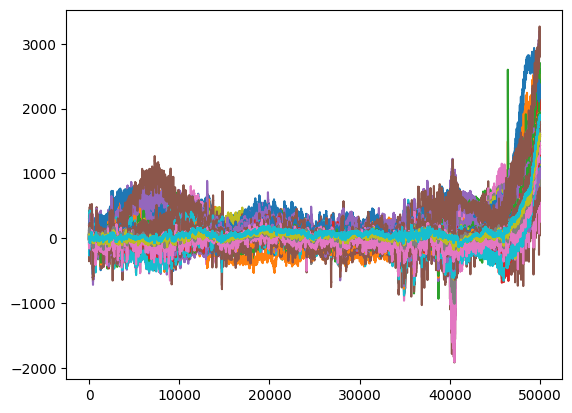

In [2]:
import scipy.io as sio
import pandas as pd

data_path = "/home/kslote/Desktop/epilepsy/data/E3Data.mat"
e3data = sio.loadmat(data_path)
X = e3data['X1']
df = pd.DataFrame(X,
    columns=[f"{column_index}" for column_index in range(120)] 
)
df.plot(legend=False)

In [3]:
import numpy as np

# Calculate frequency for each channel
def estimate_omega(data, dt=1):
    # Get phase using Hilbert transform
    from scipy.signal import hilbert
    analytic_signal = hilbert(data)
    phase = np.unwrap(np.angle(analytic_signal))
    # Average frequency is slope of unwrapped phase
    omega = np.diff(phase) / dt
    return np.mean(omega)

# Calculate for each channel
omegas = [estimate_omega(X[:,i]) for i in range(X.shape[1])]
omega = np.array(omegas)

In [90]:
import numpy as np
import xgi
from xgi.dynamics.synchronization import simulate_kuramoto,simulate_simplicial_kuramoto

# Rescale simulation parameters
dt = 0.01  # Smaller time step
t_final = 49972  # Longer simulation time
times = np.arange(0, t_final, dt)
theta = np.linspace(0, 2*np.pi, n)

n = 120
# #H = xgi.random_hypergraph(n, [0.05, 0.001], seed=42)

# # Adjust coupling strengths 
# k2 = 0.1  # Weaker coupling for more variability
# k3 = 2.5 # These work ok

# # Adjust coupling strengths 
# # k2 = 5.201  # Weaker coupling for more variability
# # k3 = 20.0
# k2 = 0.01
# k3 = 10
# k2 = 14.66392505
# k3 = -14.15139607
k2 = 14.66392505
k3 = -24.15139607 # These look like the best
# k2 = k2_opt
# k3 = k3_opt
# k2 = 0.1 
# k3 = 0.5
# k2 = 0.09999822227576408
# k3 =0.4999911111654312

#k1 = 5.760668479259185
#k = -5.503739296183984

# Phi optimized
k2: 0.09999822227576408
k3= 0.4999911111654312

#H2 = xgi.random_hypergraph(n, [0.05, 0.001], seed=42)
theta_time, times = simulate_kuramoto(H, k2=k2, k3=k3, omega=omega, 
                                    theta=theta,
                                    timesteps= 49972,
                                    #t_span=[0, t_final], 
                                    dt=dt)

# Scale output to match data amplitude
scaling_factor = np.std(X) / np.std(theta_time)
theta_time_scaled = theta_time * scaling_factor

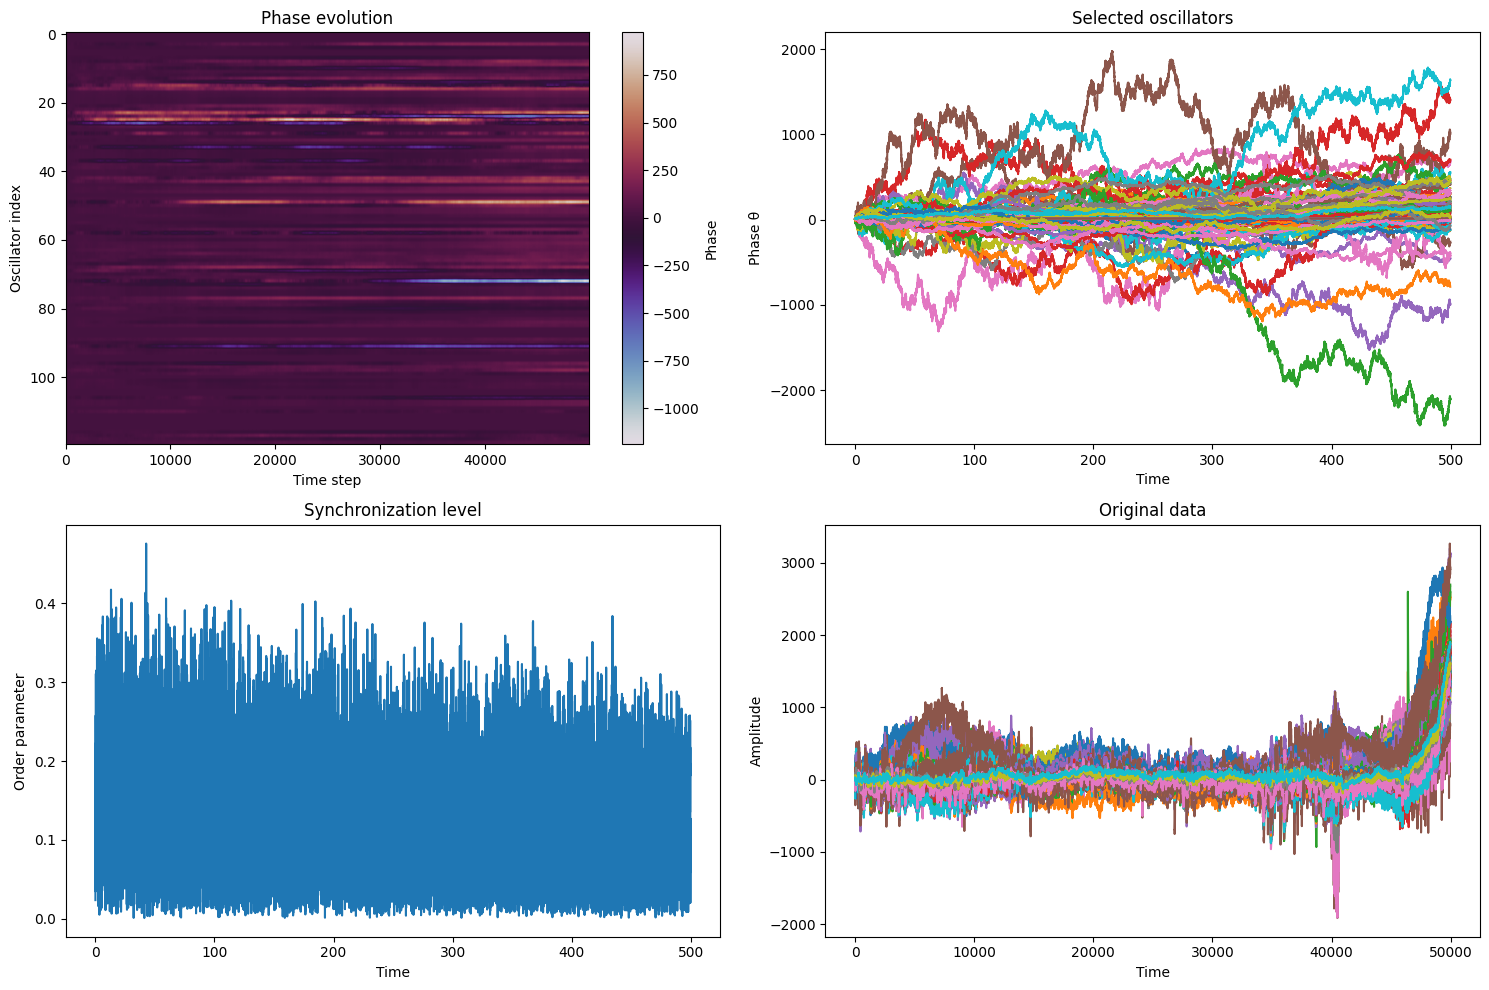

In [89]:
import matplotlib.pyplot as plt

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))


im = ax1.imshow(theta_time.T, aspect='auto', cmap='twilight')
fig.colorbar(im, ax=ax1, label='Phase')
ax1.set_xlabel('Time step')
ax1.set_ylabel('Oscillator index')
ax1.set_title('Phase evolution')

ax2.plot(times, theta_time_scaled)
ax2.set_xlabel('Time')
ax2.set_ylabel('Phase θ')
ax2.set_title('Selected oscillators')

# Order parameter
r = np.abs(np.mean(np.exp(1j * theta_time_scaled), axis=1))
ax3.plot(times, r)
ax3.set_xlabel('Time')
ax3.set_ylabel('Order parameter')
ax3.set_title('Synchronization level')


ax4.set_xlabel('Time')
ax4.set_ylabel('Amplitude')
ax4.set_title('Original data')

plt.tight_layout()
plt.show()

In [86]:
print("hi")

hi


In [4]:
from feature_extractors.granger_causation import GrangerCausality

gc = GrangerCausality()
G, W = gc.fit(df.to_numpy().T, lag=10)

In [ ]:
H = xgi.Hypergraph()
H.add_nodes_from(G.nodes())
H.add_edges_from(G.edges())


# Add triangles from graph
for i in G.nodes():
    neighbors_i = list(G.neighbors(i))
    for j in neighbors_i:
        for k in neighbors_i:
            if j < k and G.has_edge(j,k):
                H.add_edge([i,j,k])

In [ ]:
import networkx as nx
H = xgi.Hypergraph()
H.add_nodes_from(G.nodes())
H.add_edges_from(G.edges())

K = G.copy()
K = K.to_undirected()
# Add triangles using NetworkX's find_cliques
triangles = [c for c in nx.find_cliques(K) if len(c) == 3]
H.add_edges_from(triangles)
triangles

In [7]:
import numpy as np
from scipy.signal import welch

def estimate_omega_fft(data, fs=1.0):

    # Compute power spectral density (PSD)
    freqs, psd = welch(data, fs=fs, nperseg=len(data)//8)

    # Compute cumulative power distribution
    cdf = np.cumsum(psd) / np.sum(psd)

    # Find the frequency where 50% of the total power is accumulated (median frequency)
    median_freq = freqs[np.searchsorted(cdf, 0.5)]

    return median_freq

# Apply this to each channel
omegas = [estimate_omega_fft(X[:, i]) for i in range(X.shape[1])]
omega = np.array(omegas)

In [74]:
from scipy.optimize import minimize
import numpy as np

def simulate_and_compare(params, H, theta, omega, X_true):
    k2, k3 = params
    #theta_time, _ = simulate_kuramoto(H, k2=k2, k3=k3, omega=omega, theta=theta)
    theta_time_opt, times = simulate_kuramoto(
        H, k2=k2, k3=k3,
        timesteps= 49972,
        omega=omega, theta=theta)
    scaling_factor = np.std(X_true) / np.std(theta_time)
    theta_time_scaled = theta_time_opt * scaling_factor
    
    return np.mean((theta_time_scaled[30000:] - X_true[30000:len(times)])**2)

# Initial guess
initial_params = [0.1, 0.5]

# Optimize
result = minimize(simulate_and_compare, initial_params, 
                 args=(H, theta, omega, X),
                 bounds=[(-10, 10), (-10, 10)])

k2_opt, k3_opt = result.x
print(f"Optimal k2: {k2_opt}, k3: {k3_opt}")

Optimal k2: 5.760668479259185, k3: -5.503739296183984


In [ ]:
results.x

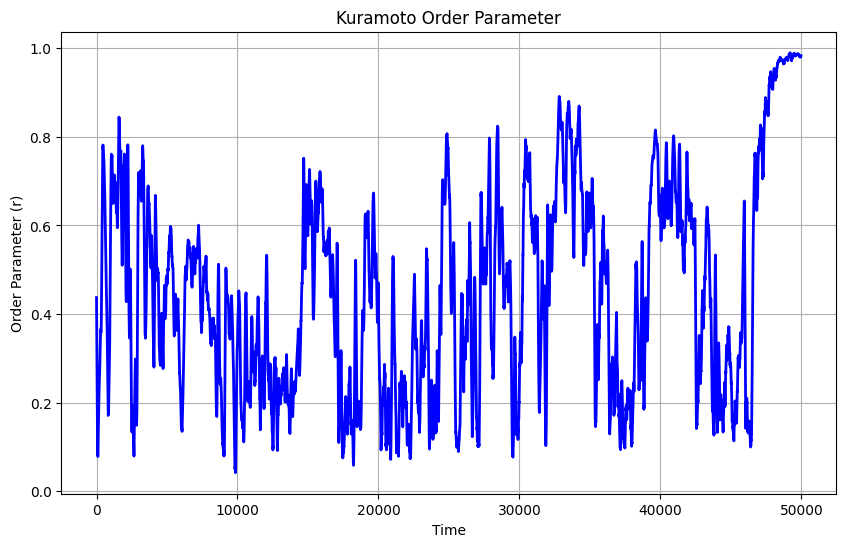

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from xgi.dynamics.synchronization import compute_kuramoto_order_parameter
from scipy.signal import hilbert, savgol_filter



def coherence(X, window_length=200, poly_order=3):
    phi = np.unwrap(np.angle(hilbert(X)))
    kph = savgol_filter(np.abs(np.mean(np.exp(1j*phi), axis=1)), poly_order)
    return kphi

def coherence(X, window_length=200, poly_order=3):
    phi = np.unwrap(np.angle(hilbert(X)))
    kph = savgol_filter(np.abs(np.mean(np.exp(1j*phi), axis=1)), 
                       window_length=window_length, 
                       polyorder=poly_order)
    return kph

def coherence(X, window_length=99, poly_order=3):  # Changed to 99 (odd number < 120)
    phi = np.unwrap(np.angle(hilbert(X)))
    kph = savgol_filter(np.abs(np.mean(np.exp(1j*phi), axis=1)), 
                       window_length=window_length, 
                       polyorder=poly_order)
    return kph

def coherence(X, window_length=99, poly_order=1):
    # 1. You could try filtering the raw data first before Hilbert transform
    # X = scipy.signal.filtfilt(b, a, X) # if you want to add bandpass filtering
    
    # 2. The Hilbert transform is sensitive to noise, you might want to normalize first
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    
    # 3. Calculate phases
    phi = np.unwrap(np.angle(hilbert(X_norm)))
    
    # 4. Calculate order parameter
    r = np.abs(np.mean(np.exp(1j*phi), axis=1))
    
    # 5. Smoothing - you can adjust window_length and poly_order
    kph = savgol_filter(r, window_length=window_length, polyorder=poly_order)
    return kph

data = X
#phi = compute_kuramoto_order_parameter(data)
phi = coherence(data)



# # Plot
plt.figure(figsize=(10, 6))
plt.plot(phi, 'b-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Order Parameter (r)')
plt.title('Kuramoto Order Parameter')
plt.grid(True)
#plt.ylim(0, 0.011)  # Since r is bounded between 0 and 1
plt.show()

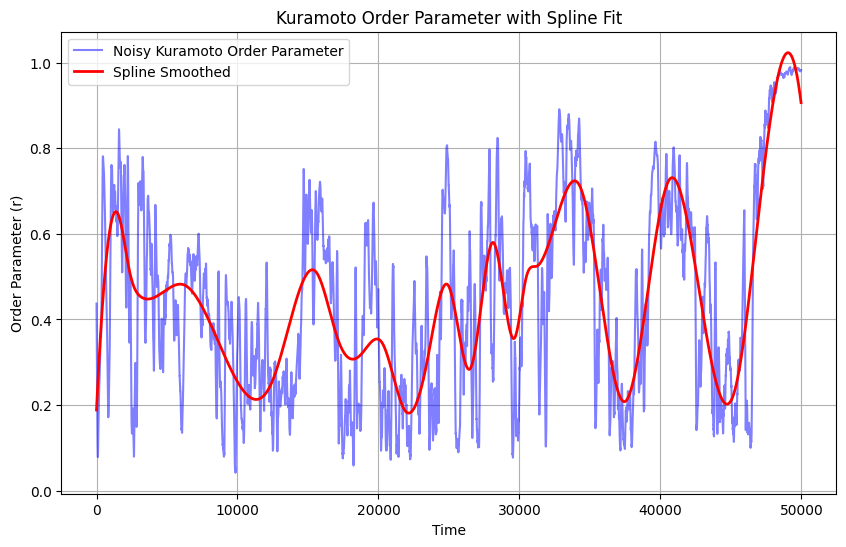

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, savgol_filter
from scipy.interpolate import UnivariateSpline

# Define a function to fit the curve using UnivariateSpline
def fit_spline(time, signal, smoothing_factor=0.002):
    """
    Fits a spline to the given signal and returns the smoothed curve.
    
    Parameters:
        time (array-like): The time points
        signal (array-like): The noisy signal
        smoothing_factor (float): The smoothing parameter for the spline
        
    Returns:
        spline_function (UnivariateSpline): The fitted spline function
    """
    spline = UnivariateSpline(time, signal, s=smoothing_factor * len(time))
    return spline

# Example usage with your coherence function output
time = np.arange(len(phi))  # Assuming uniform time steps
spline = fit_spline(time, phi, smoothing_factor=0.02)  # Adjust smoothing_factor as needed

# Generate smoothed values
phi_smooth = spline(time)

# Plot the original and smoothed signals
plt.figure(figsize=(10, 6))
plt.plot(time, phi, 'b-', alpha=0.5, label='Noisy Kuramoto Order Parameter')
plt.plot(time, phi_smooth, 'r-', linewidth=2, label='Spline Smoothed')
plt.xlabel('Time')
plt.ylabel('Order Parameter (r)')
plt.title('Kuramoto Order Parameter with Spline Fit')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from scipy.optimize import minimize
import numpy as np
from scipy.signal import hilbert

def coherence(X, window_length=99, poly_order=3):
    # 1. You could try filtering the raw data first before Hilbert transform
    # X = scipy.signal.filtfilt(b, a, X) # if you want to add bandpass filtering
    
    # 2. The Hilbert transform is sensitive to noise, you might want to normalize first
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    
    # 3. Calculate phases
    phi = np.unwrap(np.angle(hilbert(X_norm)))
    
    # 4. Calculate order parameter
    r = np.abs(np.mean(np.exp(1j*phi), axis=1))
    
    # 5. Smoothing - you can adjust window_length and poly_order
    kph = savgol_filter(r, window_length=window_length, polyorder=poly_order)
    return kph

def simulate_and_compare(params, H, theta, omega, X_true):
    k2, k3 = params
    
    # Simulate your Kuramoto model
    theta_time, times = simulate_kuramoto(
        H, k2=k2, k3=k3,
        timesteps= 49972,
        omega=omega, theta=theta)
    time = np.arange(len(theta_time))
    spline = fit_spline(time, theta_time, smoothing_factor=0.02)  # Adjust smoothing_factor as needed    # Calculate order parameter for simulated data
    r_sim = spline(time)
    #r_sim = fit_spline(coherence(theta_time.T))
    
    # Calculate order parameter for true data
    phi = coherence(X_true.T)
    time = np.arange(len(phi))
    spline = fit_spline(time, phi, smoothing_factor=0.02)
    r_true = spline(time)
    
    
    # Compare order parameters (trim to same length)
    #min_len = min(len(r_sim), len(r_true))
    #mse = np.mean((r_sim[:min_len] - r_true[:min_len])**2)
    mse = np.mean((r_sim - r_true)**2)
    return mse

# Initial guess
initial_params = [0.1, 0.5]

# Optimize with bounds
result = minimize(simulate_and_compare, initial_params, 
                 args=(H, theta, omega, X),
                 bounds=[(-10, 10), (-10, 10)],
                 method='L-BFGS-B')  # Added method specification

k2_opt, k3_opt = result.x
print(f"Optimal k2: {k2_opt}, k3: {k3_opt}")
print(f"Final MSE: {result.fun}")

# Plot comparison of order parameters with optimal parameters
theta_time_opt, times = simulate_kuramoto(H, k2=k2_opt, k3=k3_opt, omega=omega, theta=theta)
r_sim_opt = calculate_order_parameter(theta_time_opt.T)
r_true = calculate_order_parameter(X.T)

plt.figure(figsize=(10, 6))
plt.plot(r_true, 'b-', label='True Order Parameter')
plt.plot(r_sim_opt, 'r--', label='Simulated Order Parameter')
plt.xlabel('Time')
plt.ylabel('Order Parameter (r)')
plt.title('Comparison of True vs Simulated Order Parameters')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from scipy.signal import hilbert, savgol_filter
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

def fit_spline(time, signal, smoothing_factor=0.01):
    """
    Fits a spline to the given signal and returns the smoothed curve.
    
    Parameters:
        time (array-like): The time points
        signal (array-like): The noisy signal
        smoothing_factor (float): The smoothing parameter for the spline
        
    Returns:
        spline_function (UnivariateSpline): The fitted spline function
    """
    # Normalize time to [0,1] for numerical stability
    time_norm = (time - time.min()) / (time.max() - time.min())
    spline = UnivariateSpline(time_norm, signal, s=smoothing_factor * len(time))
    return lambda x: spline((x - time.min()) / (time.max() - time.min()))

def spline_distance(spline1, spline2, t_start, t_end, num_points=1000):
    """
    Compute L2 distance between two spline functions over an interval.
    
    Parameters:
        spline1, spline2: Callable spline functions
        t_start, t_end: Integration interval bounds
        num_points: Number of points for numerical integration
        
    Returns:
        float: The L2 distance between the splines
    """
    integrand = lambda t: (spline1(t) - spline2(t))**2
    distance, _ = quad(integrand, t_start, t_end)
    return np.sqrt(distance)

def simulate_and_compare(params, H, theta, omega, X_true):
    k2, k3 = params
    
    # Simulate Kuramoto model
    theta_time, time = simulate_kuramoto(H, k2=k2, k3=k3, omega=omega, theta=theta)
    
    # Fit splines to both simulated and true data
    time_array = np.arange(len(theta_time))
    sim_spline = fit_spline(time_array, coherence(theta_time.T))
    true_spline = fit_spline(time_array, coherence(X_true.T))
    
    # Compare splines over the entire time interval
    t_start, t_end = time_array[0], time_array[-1]
    distance = spline_distance(sim_spline, true_spline, t_start, t_end)
    
    return distance

# Optimization with improved objective function
from scipy.optimize import minimize

initial_params = [0.1, 0.5]
result = minimize(simulate_and_compare, 
                 initial_params,
                 args=(H, theta, omega, X),
                 bounds=[(-10, 10), (-10, 10)],
                 method='L-BFGS-B')

k2_opt, k3_opt = result.x
print(f"Optimal k2: {k2_opt}, k3: {k3_opt}")
print(f"Final L2 distance: {result.fun}")

# Visualization
def plot_comparison(H, theta, omega, X, k2_opt, k3_opt):
    theta_time_opt, times = simulate_kuramoto(H, k2=k2_opt, k3=k3_opt, omega=omega, theta=theta)
    
    time_array = np.arange(len(theta_time_opt))
    sim_spline = fit_spline(time_array, coherence(theta_time_opt.T))
    true_spline = fit_spline(time_array, coherence(X.T))
    
    # Generate smooth curves for plotting
    t_plot = np.linspace(time_array[0], time_array[-1], 1000)
    sim_curve = [sim_spline(t) for t in t_plot]
    true_curve = [true_spline(t) for t in t_plot]
    
    plt.figure(figsize=(12, 6))
    plt.plot(t_plot, true_curve, 'b-', label='True Order Parameter')
    plt.plot(t_plot, sim_curve, 'r--', label='Simulated Order Parameter')
    plt.xlabel('Time')
    plt.ylabel('Order Parameter (r)')
    plt.title('Comparison of True vs Simulated Order Parameters (Spline Fitted)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [64]:
import numpy as np
from scipy.signal import hilbert, savgol_filter
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

def coherence(X, window_length=99, poly_order=3):
    """
    Calculate coherence with consistent output length.
    """
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    phi = np.unwrap(np.angle(hilbert(X_norm)))
    r = np.abs(np.mean(np.exp(1j*phi), axis=1))
    kph = savgol_filter(r, window_length=window_length, polyorder=poly_order)
    return kph

def fit_spline(time, signal, smoothing_factor=0.01):
    """
    Fits a spline to the given signal with proper length checking.
    """
    if len(time) != len(signal):
        raise ValueError(f"Length mismatch: time ({len(time)}) != signal ({len(signal)})")
    
    # Ensure data is 1D
    signal = np.asarray(signal).ravel()
    time = np.asarray(time).ravel()
    
    # Remove any NaN values
    valid_mask = ~np.isnan(signal) & ~np.isnan(time)
    time = time[valid_mask]
    signal = signal[valid_mask]
    
    # Normalize time to [0,1]
    time_norm = (time - time.min()) / (time.max() - time.min())
    spline = UnivariateSpline(time_norm, signal, s=smoothing_factor * len(time))
    return lambda x: spline((x - time.min()) / (time.max() - time.min()))

def simulate_and_compare(params, H, theta, omega, X_true):
    k2, k3 = params
    
    # Simulate Kuramoto model
    theta_time_opt, times = simulate_kuramoto(
        H, k2=k2_opt, k3=k3_opt,
        timesteps= 49972,
        omega=omega, theta=theta)
    
    # Calculate coherence for both datasets
    sim_coherence = coherence(theta_time)
    true_coherence = coherence(X_true)
    
    # Create time arrays of matching length
    time_sim = np.arange(len(sim_coherence))
    time_true = np.arange(len(true_coherence))
    
    # Fit splines
    sim_spline = fit_spline(time_sim, sim_coherence, smoothing_factor=0.002)
    true_spline = fit_spline(time_true, true_coherence, smoothing_factor=0.002)
    
    # Use the shorter time range for comparison
    t_end = min(len(sim_coherence), len(true_coherence))
    t_eval = np.linspace(0, t_end-1, 1000)
    
    # Compare splines at evaluation points
    sim_values = np.array([sim_spline(t) for t in t_eval])
    true_values = np.array([true_spline(t) for t in t_eval])
    
    # Calculate MSE
    mse = np.mean((sim_values - true_values)**2)
    return mse

# Optimization setup
initial_params = [0.1, 0.5]
result = minimize(simulate_and_compare, 
                 initial_params,
                 args=(H, theta, omega, X),
                 bounds=[(-100, 100), (-100, 100)],
                 method='trust-constr')

k2_opt, k3_opt = result.x
print(f"Optimal k2: {k2_opt}, k3: {k3_opt}")
print(f"Final MSE: {result.fun}")


Optimal k2: 0.09999822227576408, k3: 0.4999911111654312
Final MSE: 0.17309099304957343


/home/kslote/anaconda3/envs/epilepsy_mds/lib/python3.9/site-packages/scipy/optimize/_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


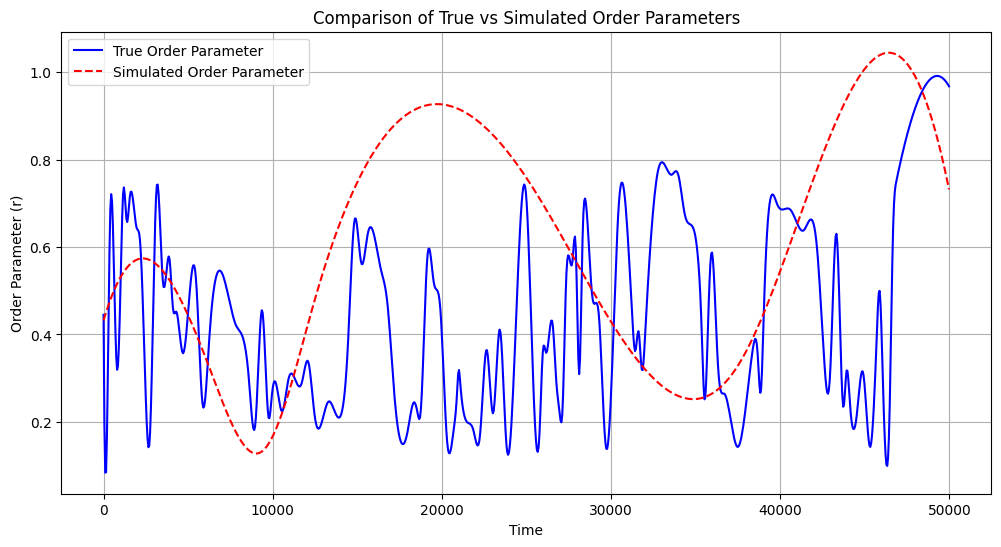

In [65]:
def plot_comparison(H, theta, omega, X, k2_opt, k3_opt):
    """
    Plot the comparison with proper length handling.
    """
    theta_time_opt, times = simulate_kuramoto(
        H, k2=k2_opt, k3=k3_opt,
        timesteps= 49972,
        omega=omega, theta=theta)
    
    # Calculate coherence
    sim_coherence = coherence(theta_time_opt)
    true_coherence = coherence(X)
    
    # Create time arrays
    time_sim = np.arange(len(sim_coherence))
    time_true = np.arange(len(true_coherence))
    
    # Fit splines
    sim_spline = fit_spline(time_sim, sim_coherence)
    true_spline = fit_spline(time_true, true_coherence)
    
    # Use common time range for plotting
    t_end = min(len(sim_coherence), len(true_coherence))
    t_plot = np.linspace(0, t_end-1, 1000)
    
    # Generate curves
    sim_curve = np.array([sim_spline(t) for t in t_plot])
    true_curve = np.array([true_spline(t) for t in t_plot])
    
    plt.figure(figsize=(12, 6))
    plt.plot(t_plot, true_curve, 'b-', label='True Order Parameter')
    plt.plot(t_plot, sim_curve, 'r--', label='Simulated Order Parameter')
    plt.xlabel('Time')
    plt.ylabel('Order Parameter (r)')
    plt.title('Comparison of True vs Simulated Order Parameters')
    plt.legend()
    plt.grid(True)
    plt.show()

# Is this the one I am even working on? Think so.
plot_comparison(H, theta, omega, X, k2_opt, k3_opt)

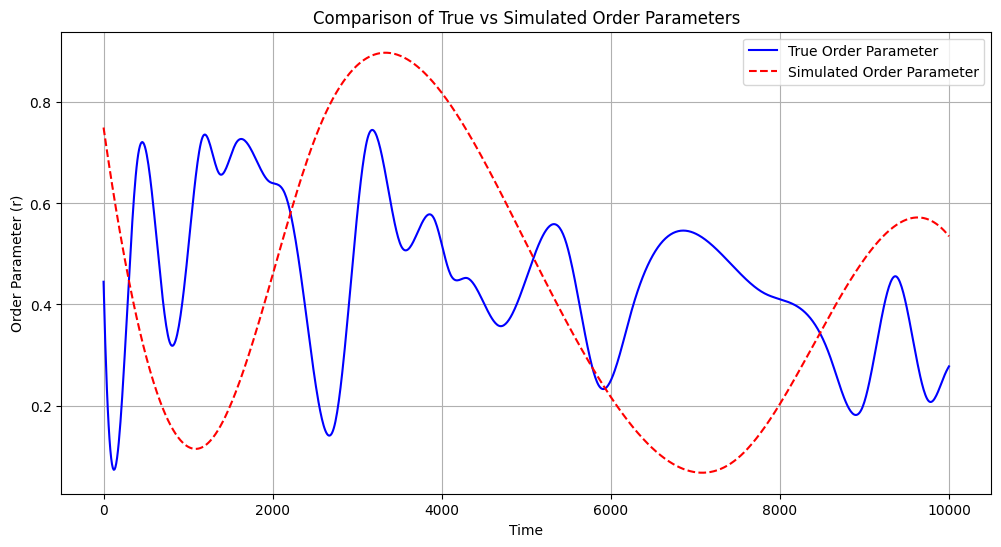

In [ ]:
def plot_comparison(H, theta, omega, X, k2_opt, k3_opt):
    """
    Plot the comparison with proper length handling.
    """
    theta_time_opt, times = simulate_kuramoto(H, k2=k2_opt, k3=k3_opt, omega=omega, theta=theta)
    
    # Calculate coherence
    sim_coherence = coherence(theta_time_opt)
    true_coherence = coherence(X)
    
    # Create time arrays
    time_sim = np.arange(len(sim_coherence))
    time_true = np.arange(len(true_coherence))
    
    # Fit splines
    sim_spline = fit_spline(time_sim, sim_coherence)
    true_spline = fit_spline(time_true, true_coherence)
    
    # Use common time range for plotting
    t_end = min(len(sim_coherence), len(true_coherence))
    t_plot = np.linspace(0, t_end-1, 1000)
    
    # Generate curves
    sim_curve = np.array([sim_spline(t) for t in t_plot])
    true_curve = np.array([true_spline(t) for t in t_plot])
    
    plt.figure(figsize=(12, 6))
    plt.plot(t_plot, true_curve, 'b-', label='True Order Parameter')
    plt.plot(t_plot, sim_curve, 'r--', label='Simulated Order Parameter')
    plt.xlabel('Time')
    plt.ylabel('Order Parameter (r)')
    plt.title('Comparison of True vs Simulated Order Parameters')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_kuramoto_spline(phi, t_end=49972, num_points=1000):
    """
    Plot Kuramoto order parameter with spline fit using same resolution as comparison plot.
    
    Parameters:
        phi: raw order parameter data
        t_end: end time to match first plot (default 10000)
        num_points: number of points for interpolation (default 1000)
    """
    # Create time arrays matching the first plot
    time_raw = np.linspace(0, t_end, len(phi))
    t_plot = np.linspace(0, t_end, num_points)
    
    # Fit spline with similar smoothing as first plot
    spline = UnivariateSpline(time_raw, phi, s=0.01 * len(phi))  # Adjust smoothing to match
    phi_smooth = spline(t_plot)
    
    plt.figure(figsize=(12, 6))  # Match figure size with first plot
    plt.plot(time_raw, phi, 'b-', alpha=0.5, label='Noisy Kuramoto Order Parameter')
    plt.plot(t_plot, phi_smooth, 'r-', linewidth=2, label='Spline Smoothed')
    plt.xlabel('Time')
    plt.ylabel('Order Parameter (r)')
    plt.title('Kuramoto Order Parameter with Spline Fit')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, t_end)  # Set same x-axis limits as first plot
    plt.ylim(0, 1.0)    # Set reasonable y-axis limits
    plt.show()
    
plot_comparison(H, theta, omega, X, k2_opt, k3_opt)

In [45]:
X.shape

(49972, 120)

In [46]:
theta_time_opt, times = simulate_kuramoto(
    H, k2=k2_opt, k3=k3_opt,
    timesteps= 49972,
    dt=0.002,
    omega=omega, theta=theta)

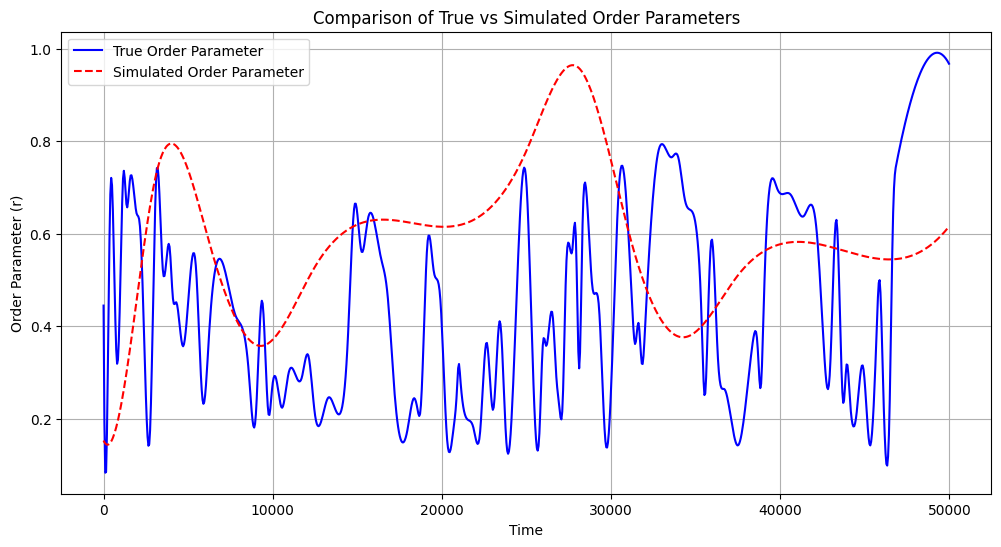

In [47]:
#theta_time_opt, times = simulate_kuramoto(H, k2=k2_opt, k3=k3_opt, omega=omega, theta=theta)
    
# Calculate coherence
sim_coherence = coherence(theta_time_opt)
true_coherence = coherence(X)
    
# Create time arrays
time_sim = np.arange(len(sim_coherence))
time_true = np.arange(len(true_coherence))
    
# Fit splines
sim_spline = fit_spline(time_sim, sim_coherence)
true_spline = fit_spline(time_true, true_coherence)
    
# Use common time range for plotting
t_end = min(len(sim_coherence), len(true_coherence))
t_plot = np.linspace(0, t_end-1, 1000)
    
# Generate curves
sim_curve = np.array([sim_spline(t) for t in t_plot])
true_curve = np.array([true_spline(t) for t in t_plot])
    
plt.figure(figsize=(12, 6))
plt.plot(t_plot, true_curve, 'b-', label='True Order Parameter')
plt.plot(t_plot, sim_curve, 'r--', label='Simulated Order Parameter')
plt.xlabel('Time')
plt.ylabel('Order Parameter (r)')
plt.title('Comparison of True vs Simulated Order Parameters')
plt.legend()
plt.grid(True)
plt.show()